In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [5]:
df = pd.read_csv("Titanic-Dataset.csv") #loading data 
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [6]:
print(df.shape)
print(df.isnull().sum()) # missing value 

(891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


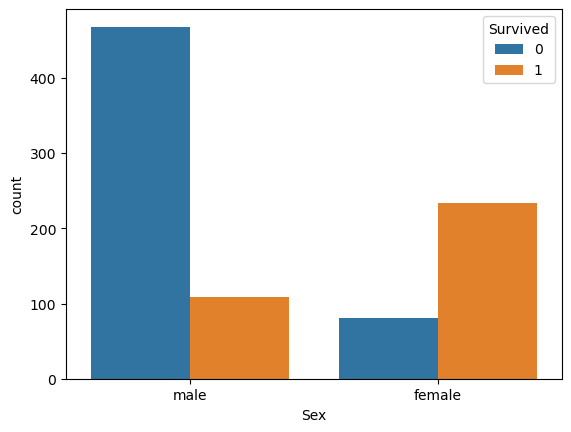

In [8]:
sns.countplot(x="Sex", hue="Survived", data=df) # visualization 
plt.show()


In [9]:
df["Age"].fillna(df["Age"].mean(), inplace=True)    # handling missing value 
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

C:\Users\enggb\AppData\Local\Temp\ipykernel_2028\3238960623.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)
C:\Users\enggb\AppData\Local\Temp\ipykernel_2028\3238960623.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [13]:
le = LabelEncoder()    #encoding 

df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])


In [14]:
X = df[["Pclass","Sex","Age","Fare","Embarked"]]    #feature scalling 
y = df["Survived"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(       # train_test_split 
    X, y, test_size=0.2, random_state=42
)

In [16]:
model = LogisticRegression()         # model training 
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)    # prediction accuracy 
print("Accuracy:", accuracy)

Accuracy: 0.7988826815642458


In [19]:
from sklearn.metrics import confusion_matrix # confusion matrix
print(confusion_matrix(y_test, y_pred))

[[88 17]
 [19 55]]


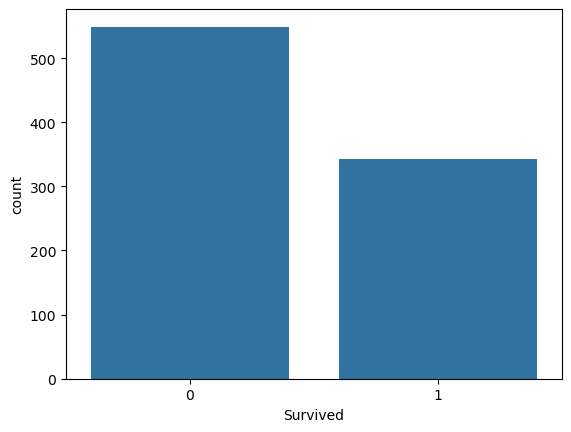

In [20]:
sns.countplot(x="Survived", data=df)
plt.show()

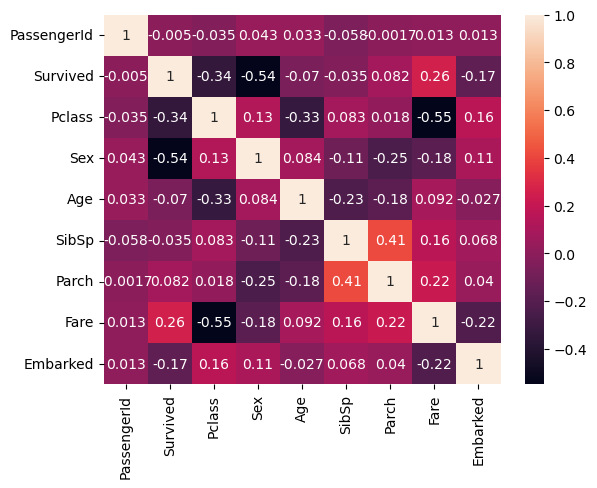

In [21]:
sns.heatmap(df.select_dtypes(include=["number"]).corr(), annot=True)
plt.show()